In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import glob, os, sparse, sys, warnings, yaml, vcf, pickle, shutil, subprocess, re
import scipy.optimize

os.chdir("../")
who_variants = pd.read_csv("./data_processing/data_utils/WHO_catalog_V2.csv", header=[2]).reset_index(drop=True)

coll_2014 = pd.read_csv("./data_processing/data_utils/coll2014_SNP_scheme.tsv", sep="\t")
freschi_2020 = pd.read_csv("./data_processing/data_utils/freschi2020_SNP_scheme.tsv", sep="\t")
lineages_matrix = pd.read_csv("/n/data1/hms/dbmi/farhat/Sanjana/MIC_data/lineage_matrix_Coll2014.csv", index_col=[0])

sys.path.append("utils")
from data_utils import *
from analysis_utils import *
from inSilicoMut_utils import *
import seaborn as sns
import scipy.stats as st
plt.rcParams['figure.dpi'] = 150
import statsmodels.stats.api as sm

from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split, KFold, StratifiedKFold
from sklearn.linear_model import Ridge, RidgeCV, LinearRegression

from Bio import SeqIO
warnings.filterwarnings("ignore")

data_dir = "/n/data1/hms/dbmi/farhat/Sanjana/MIC_data/single_drugs"
genomic_data_dir = "/n/data1/hms/dbmi/farhat/rollingDB/genomic_data"
results_dir = "/n/data1/hms/dbmi/farhat/Sanjana/CNN_results"

#cc_df = pd.read_csv("/n/data1/hms/dbmi/farhat/Sanjana/MIC_data/criticalConcentrations_updated.csv")
cc_df = pd.read_csv("/n/data1/hms/dbmi/farhat/rollingDB/metadata/MIC/critical_concentrations_all.csv")

drug_abbr_dict = {"Delamanid": "DLM",
                  "Bedaquiline": "BDQ",
                  "Clofazimine": "CFZ",
                  "Ethionamide": "ETO",
                  "Linezolid": "LZD",
                  "Moxifloxacin": "MXF",
                  "Capreomycin": "CAP",
                  "Amikacin": "AMK",
                  "Pretomanid": "PMD",
                  "Pyrazinamide": "PZA",
                  "Kanamycin": "KAN",
                  "Levofloxacin": "LFX",
                  "Streptomycin": "STM",
                  "Ethambutol": "EMB",
                  "Isoniazid": "INH",
                  "Rifampicin": "RIF"
                 }

abbr_drug_dict = {value: key for key, value in drug_abbr_dict.items()}

model_loci = pd.read_csv("./data_processing/data_utils/drug_loci.csv")
model_loci[['Start', 'End']] = model_loci[['Start', 'End']].astype(int)

cryptic_wgs_metadata = pd.read_csv("/n/data1/hms/dbmi/farhat/rollingDB/metadata/cryptic_WGS_metadata.csv")
df_cryptic = pd.read_csv("MIC_data/CRyPTIC_reuse_table_20231208.csv")
df_geno = pd.read_csv("./data_processing/samples_pass_geno_QC.csv")

cc_dict = {'RIF': 0.5, 'INH': 0.2, 'EMB': 5, 'PZA': 100, 'ETO': 5, 'MXF': 0.5, 'LFX': 1, 'BDQ': 0.25, 'LZD': 1, 'CFZ': 1, 'DLM': 0.016}
drugs_lst = ['BDQ', 'EMB', 'ETO', 'INH', 'LFX', 'MXF', 'PZA', 'RIF']

isolate_variants = pd.read_csv(os.path.join(os.path.dirname(data_dir), "isolate_WHO_catalog_variants.csv")).dropna(subset='variant').reset_index(drop=True)

/tmp/ipykernel_12298/3562296313.py:8: DtypeWarning: Columns (36,37,99,100,102,103,106,108,112) have mixed types. Specify dtype option on import or set low_memory=False.
  who_variants = pd.read_csv("./data_processing/data_utils/WHO_catalog_V2.csv", header=[2]).reset_index(drop=True)


In [2]:
df_geno = pd.read_csv("./data_processing/samples_pass_geno_QC.csv")

cc_dict = {'RIF': 0.5, 'INH': 0.2, 'EMB': 5, 'PZA': 100, 'ETO': 5, 'MXF': 0.5, 'LFX': 1, 'BDQ': 0.25, 'LZD': 1, 'CFZ': 1, 'DLM': 0.016}
drugs_lst = ['BDQ', 'EMB', 'ETO', 'INH', 'LFX', 'MXF', 'PZA', 'RIF']

isolate_variants = pd.read_csv(os.path.join(os.path.dirname(data_dir), "isolate_WHO_catalog_variants.csv")).dropna(subset='variant').reset_index(drop=True)

# 1. Get Binary data from the WHO catalog

In [15]:
def get_binary_samples_to_add(drug):
    
    sample_ids_mapping = pd.read_csv("~/who-analysis/lineages/combined_lineages_samples.csv")
    phenos_binary = pd.read_csv(f"./analysis/{drug}_WHO_catalog_phenos_binary.csv")

    df_before_QC = pd.read_csv(f"{data_dir}/{drug}/combined_MIC.csv")

    df_binary = sample_ids_mapping.merge(phenos_binary, left_on='Sample_ID', right_on='sample_id')[['BioSample', 'Sample_Name', 'Lineage', 'phenotypic_category', 'phenotype']]
    print(f"{len(df_binary.dropna(subset='BioSample'))}/{len(df_binary)} samples are public")
    df_binary = df_binary.dropna(subset='BioSample')

    df_binary['MIC'] = df_binary['BioSample'].isin(df_before_QC.ROLLINGDB_ID).astype(int)
    print(f"{df_binary.MIC.sum()} samples are already in the MIC dataset")
    
    num_WHO_datapoints = len(df_binary.query("phenotypic_category=='WHO'"))
    print(f"{num_WHO_datapoints} samples are in the WHO dataset")

    # keep only those that are not in the CNN MIC dataset and are in the WHO dataset
    df_binary = df_binary.query("MIC==0 & phenotypic_category=='WHO' & ~BioSample.str.contains('_')").reset_index(drop=True)
    print("\n")

    return df_binary

In [16]:
BDQ_binary = get_binary_samples_to_add('BDQ')
PZA_binary = get_binary_samples_to_add('PZA')

12462/14135 samples are public
8712 samples are already in the MIC dataset
1660 samples are in the WHO dataset


14961/21319 samples are public
1146 samples are already in the MIC dataset
13566 samples are in the WHO dataset




In [48]:
df_PZA = pd.read_csv(f"{data_dir}/PZA/data_for_model.csv").query("Span_CC==0")

In [92]:
PZA_binary_R = PZA_binary.query("phenotype==1").reset_index(drop=True)
PZA_binary_S = PZA_binary.query("phenotype==0").reset_index(drop=True)

In [94]:
for i, row in PZA_binary_R.iterrows():
    if os.path.isfile(f"/n/data1/hms/dbmi/farhat/rollingDB/genomic_data/{row['BioSample']}/pilon/{row['BioSample']}_variants.vcf"):
        PZA_binary_R.loc[i, 'QC'] = 1
    else:
        if os.path.isdir(f"/n/data1/hms/dbmi/farhat/rollingDB/genomic_data/{row['BioSample']}"):
            PZA_binary_R.loc[i, 'QC'] = 0
        
for i, row in PZA_binary_S.iterrows():
    if os.path.isfile(f"/n/data1/hms/dbmi/farhat/rollingDB/genomic_data/{row['BioSample']}/pilon/{row['BioSample']}_variants.vcf"):
        PZA_binary_S.loc[i, 'QC'] = 1
    else:
        if os.path.isdir(f"/n/data1/hms/dbmi/farhat/rollingDB/genomic_data/{row['BioSample']}"):
            PZA_binary_S.loc[i, 'QC'] = 0

In [95]:
PZA_binary_R.QC.value_counts(dropna=False)

QC
NaN    1131
1.0     926
0.0     291
Name: count, dtype: int64

In [96]:
PZA_binary_S.QC.value_counts(dropna=False)

QC
1.0    6019
NaN    3221
0.0    1784
Name: count, dtype: int64

In [98]:
PZA_binary_R = PZA_binary_R.query("QC != 0").reset_index(drop=True)
PZA_binary_S = PZA_binary_S.query("QC != 0").reset_index(drop=True)

In [101]:
PZA_binary_R.QC.value_counts(dropna=False)

QC
NaN    1131
1.0     926
Name: count, dtype: int64

In [100]:
PZA_binary_S.QC.value_counts(dropna=False)

QC
1.0    6019
NaN    3221
Name: count, dtype: int64

In [102]:
PZA_binary_R_add = PZA_binary_R.sample(n=len(df_PZA), replace=False)
PZA_binary_S_add = PZA_binary_S.sample(n=len(df_PZA), replace=False)

In [103]:
len(PZA_binary_S_add), len(PZA_binary_R_add)

(1021, 1021)

In [104]:
PZA_binary_S_add.Lineage.value_counts()

Lineage
4             589
3             190
2             158
1              80
6,BOV_AFRI      1
3,4             1
1,4             1
2,4             1
Name: count, dtype: int64

In [105]:
PZA_binary_R_add.Lineage.value_counts()

Lineage
2             578
4             281
1              70
3              59
BOV_AFRI       22
2,4             5
2,3             2
4,BOV_AFRI      2
1,4             1
2,BOV_AFRI      1
Name: count, dtype: int64

In [106]:
PZA_binary_R.Lineage.value_counts()

Lineage
2             1171
4              575
1              138
3              118
BOV_AFRI        39
2,4              7
4,BOV_AFRI       3
1,4              2
2,3              2
canettii         1
2,BOV_AFRI       1
Name: count, dtype: int64

In [112]:
# pd.concat([PZA_binary_R_add, PZA_binary_S_add]).to_csv("~/data_cleaning/data/PZA_samples_to_add.csv", index=False)

In [5]:
PZA_metadata = pd.read_csv("~/Mtb_Megapipe/isolates_to_run_PZA.tsv", sep='\t', header=None)
len(PZA_metadata)

896

In [10]:
PZA_metadata.iloc[:int(len(PZA_metadata)/2)].to_csv("~/Mtb_Megapipe/isolates_to_run_PZA_1.tsv", sep='\t', header=None, index=False)
PZA_metadata.iloc[int(len(PZA_metadata)/2):].to_csv("~/Mtb_Megapipe/isolates_to_run_PZA_2.tsv", sep='\t', header=None, index=False)

In [119]:
df_for_megapipe = PZA_metadata[['BioSample', 'Run']]
df_for_megapipe['Combined_Runs'] = df_for_megapipe.groupby('BioSample')['Run'].transform(lambda x: ','.join(x))
df_for_megapipe['FQ'] = 1

In [126]:
df_for_megapipe[['BioSample', 'Combined_Runs', 'FQ']].drop_duplicates().to_csv("/home/sak0914/Mtb_Megapipe/isolates_to_run_PZA.tsv", header=None, index=False, sep='\t')

# Get BioSample Metadata

In [43]:
!module load sratoolkit/2.10.7

In [44]:
def get_biosample_metadata(search_lst):

    all_data = []

    for i, query_name in enumerate(search_lst):

        command = f'esearch -db sra -query "Mycobacterium AND {query_name}" | efetch -format runinfo'

        try:
            res = subprocess.Popen(command, shell=True, encoding='utf8', stdout=subprocess.PIPE)

            res = res.communicate()[0]

            with open("/home/sak0914/data_cleaning/intermediate_res.txt", 'w+') as file:
                file.write(res)

            res_df = pd.read_csv("/home/sak0914/data_cleaning/intermediate_res.txt")
            res_df['Query'] = query_name

            all_data.append(res_df)

        except:
            all_data.append(pd.DataFrame({"Query": query_name}, index=[i]))

        if i % 100 == 0:
            print(f"Finished {i}")

    return pd.concat(all_data)

In [18]:
# df_biosample_metadata = get_biosample_metadata(samples_to_search)

In [131]:
BDQ_binary_samples_metadata = pd.read_csv("./analysis/BDQ_binary_samples_metadata.csv").query("Platform=='ILLUMINA'").reset_index(drop=True)
BDQ_binary_samples_metadata.Query.nunique(), BDQ_binary_samples_metadata.BioSample.nunique(), BDQ_binary_samples_metadata.Run.nunique()

(867, 867, 901)

In [132]:
# 34 samples had GenoScreen DeepLex and WGS done, and they are all named <sample_name>-GS or <sample_name>-WGS, so sort and drop
BDQ_binary_samples_metadata = BDQ_binary_samples_metadata.sort_values(["BioSample", "LibraryName"]).drop_duplicates('BioSample', keep='last')
BDQ_binary_samples_metadata.Query.nunique(), BDQ_binary_samples_metadata.BioSample.nunique(), BDQ_binary_samples_metadata.Run.nunique()

(867, 867, 867)

In [137]:
len(BDQ_binary_samples_metadata.query("LibraryName.str.endswith('-GS')")), len(BDQ_binary_samples_metadata.query("LibraryName.str.endswith('-WGS')"))

(0, 34)

In [141]:
df_megapipe = BDQ_binary_samples_metadata[['BioSample', 'Run']].drop_duplicates(subset='BioSample')
df_megapipe['FQ'] = 1

In [143]:
df_megapipe.to_csv("~/Mtb_Megapipe/BDQ_binary_samples.tsv", sep='\t', header=None, index=False)

# Additional Missense Variants to Add

Restrict to isolates with a 7H11 reported MIC (not just fold change):

Rv0678_p.Trp42Arg: 0.0625-0.12 µg/mL
Rv0678_p.Trp42Arg: 0.0625-0.12 µg/mL
Rv0678_c.139_140insG: 0.12-0.25 µg/mL
Rv0678_c.140_141insG: 0.12-0.25 µg/mL
Rv0678_p.Ser53Pro: 0.25-0.5 µg/mL
Rv0678_p.Ser53Pro: 0.25-0.5 µg/mL
Rv0678_p.Ser53Pro: 0.25-0.5 µg/mL
Rv0678_p.Ser53Leu: 0.25-0.5 µg/mL
Rv0678_p.Ser53Leu: 0.25-0.5 µg/mL
Rv0678_c.274_275insA: 0.5–1 µg/mL
Rv0678_c.274_275insA: 0.5–1 µg/mL
Rv0678_p.Ser63Arg + Rv0678_p.Arg50Trp: 0.24-0.48 µg/mL
Rv0678_p.Ser63Gly + Rv0678_p.Arg50Trp: 0.24-0.48 µg/mL
Rv0678_p.Ser63Arg + Rv0678_p.Arg50Trp: 0.24-0.48 µg/mL
Rv0678_p.Ser63Gly + Rv0678_p.Arg50Trp: 0.24-0.48 µg/mL

Additional variants with only fold changes reported:

atpE_p.Asp28Val: 0.25-0.5 µg/mL
atpE_p.Asp28Pro: 
atpE_p.Asp28Asn: 0.06-0.12 µg/mL
atpE_p.Glu61Asp: 
atpE_p.Ile66Met: 0.06-0.125 µg/mL

Rv0678_p.Leu142Arg: 0.12-0.25 µg/mL
Rv0678_p.Leu142Arg + atpE_p.Ala63Val: 0.5-1 µg/mL
Rv0678_p.Gly121Glu: 0.12-0.25 µg/mL

In [9]:
variants = ['Rv0678_p.Trp42Arg', 
            'Rv0678_p.Trp42Arg',
            'Rv0678_c.139insG',
            'Rv0678_c.140insG',
            'Rv0678_p.Ser53Pro',
            'Rv0678_p.Ser53Pro',
            'Rv0678_p.Ser53Pro',
            'Rv0678_p.Ser53Leu',
            'Rv0678_p.Ser53Leu',
            'Rv0678_c.274insA',
            'Rv0678_c.274insA',
            'Rv0678_p.Ser63Arg',
            'Rv0678_p.Ser63Gly',
            'Rv0678_p.Arg50Trp',
            'Rv0678_p.Arg50Trp'
           ]

# MIC_lb = []
# MIC_ub = []

df_variants = pd.DataFrame()

df_variants['variant'] = variants
df_variants['gene'] = df_variants['variant'].str.split('_').str[0]
df_variants['mutation'] = df_variants['variant'].str.replace('Rv0678_', '')

df_variants.loc[df_variants["variant"].str.contains('ins'), 'effect'] = 'insertion'
df_variants['effect'] = df_variants['effect'].replace('nan', 'missense_variant')
df_variants['VCF_file'] = [1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 12, 13]

In [12]:
df_variants

,variant,gene,mutation,effect,VCF_file
0,Rv0678_p.Trp42Arg,Rv0678,p.Trp42Arg,missense_variant,1
1,Rv0678_p.Trp42Arg,Rv0678,p.Trp42Arg,missense_variant,2
2,Rv0678_c.139insG,Rv0678,c.139insG,insertion,3
3,Rv0678_c.140insG,Rv0678,c.140insG,insertion,4
4,Rv0678_p.Ser53Pro,Rv0678,p.Ser53Pro,missense_variant,5
5,Rv0678_p.Ser53Pro,Rv0678,p.Ser53Pro,missense_variant,6
6,Rv0678_p.Ser53Pro,Rv0678,p.Ser53Pro,missense_variant,7
7,Rv0678_p.Ser53Leu,Rv0678,p.Ser53Leu,missense_variant,8
8,Rv0678_p.Ser53Leu,Rv0678,p.Ser53Leu,missense_variant,9
9,Rv0678_c.274insA,Rv0678,c.274insA,insertion,10


In [18]:
df_for_VCF = get_data_for_synthetic_VCF(df_variants)

In [19]:
def create_synthetic_VCF_files(df, out_fName, vcf_dir):

    # assert len(df) == df.variant.nunique()
    
    # create a header section
    header = '##fileformat=VCFv4.1\n'
    header += "##contig=<ID=NC_000962.3,length=4411532>\n"
    header += '#CHROM\tPOS\tID\tREF\tALT\tQUAL\tFILTER\tINFO\tFORMAT\tSample\n'

    print(f"Creating synthetic VCF files for {df['mutation'].nunique()} mutations")

    with open(out_fName, 'w+') as out_file:
         
        # ITERATE through each mutation. N_mutations = N_files to be created. 
        # There can be multiple single site variants to make for a given mutation
        for single_VCF in df.VCF_file.unique():

            combined_mutation_str = []

            for _, row in df.query("VCF_file==@single_VCF").drop_duplicates().iterrows():
            
                # need to remove special characters
                mutation_str = row['variant'].replace('.', '_').replace('*', '+')
                combined_mutation_str.append(mutation_str)

            combined_mutation_str = '-'.join(combined_mutation_str)
    
            # absolute VCF file path
            vcf_fName = f"{vcf_dir}/{combined_mutation_str}.vcf"
            print(vcf_fName)
            
            out_file.write(vcf_fName + "\n")
                            
            # create a VCF file for the mutation
            with open(vcf_fName, 'w+') as vcf_file:

                # write VCF file header
                vcf_file.write(header)

                for _, row in df.query("VCF_file==@single_VCF").iterrows():

                    # write the variant that causes the mutation
                    vcf_file.write('\t'.join(['NC_000962.3', str(row["POS"]), '.', row["REF"], row["ALT"], '.', 'PASS', '.', 'GT', '1/1']) + '\n')

In [20]:
create_synthetic_VCF_files(df_for_VCF, "/n/data1/hms/dbmi/farhat/Sanjana/MIC_data/single_drugs/BDQ/augmented_VCF_names.txt", "/n/data1/hms/dbmi/farhat/Sanjana/MIC_data/VCF")

Creating synthetic VCF files for 9 mutations
/n/data1/hms/dbmi/farhat/Sanjana/MIC_data/VCF/Rv0678_p_Trp42Arg.vcf
/n/data1/hms/dbmi/farhat/Sanjana/MIC_data/VCF/Rv0678_p_Trp42Arg.vcf
/n/data1/hms/dbmi/farhat/Sanjana/MIC_data/VCF/Rv0678_c_139insG.vcf
/n/data1/hms/dbmi/farhat/Sanjana/MIC_data/VCF/Rv0678_c_140insG.vcf
/n/data1/hms/dbmi/farhat/Sanjana/MIC_data/VCF/Rv0678_p_Ser53Pro.vcf
/n/data1/hms/dbmi/farhat/Sanjana/MIC_data/VCF/Rv0678_p_Ser53Pro.vcf
/n/data1/hms/dbmi/farhat/Sanjana/MIC_data/VCF/Rv0678_p_Ser53Pro.vcf
/n/data1/hms/dbmi/farhat/Sanjana/MIC_data/VCF/Rv0678_p_Ser53Leu.vcf
/n/data1/hms/dbmi/farhat/Sanjana/MIC_data/VCF/Rv0678_p_Ser53Leu.vcf
/n/data1/hms/dbmi/farhat/Sanjana/MIC_data/VCF/Rv0678_c_274insA.vcf
/n/data1/hms/dbmi/farhat/Sanjana/MIC_data/VCF/Rv0678_c_274insA.vcf
/n/data1/hms/dbmi/farhat/Sanjana/MIC_data/VCF/Rv0678_p_Ser63Arg-Rv0678_p_Arg50Trp.vcf
/n/data1/hms/dbmi/farhat/Sanjana/MIC_data/VCF/Rv0678_p_Ser63Gly-Rv0678_p_Arg50Trp.vcf


In [ ]:
new_paths = [f"/n/data1/hms/dbmi/farhat/Sanjana/MIC_data/single_drugs/BDQ"]

In [ ]:
df_BDQ_with_augmentation.loc[-1, ['ROLLINGDB_ID', 
                                  'BDQ_MEDIA', 
                                  'BDQ_lower_bound', 
                                  'BDQ_midpoint', 
                                  'BDQ_upper_bound', 
                                  'MEDIA', 
                                  'DB_OF_ORIGIN']] = ['Rv0678_p_Trp42Arg',
                                                      'Rv0678_c_139insG',
                                                      'Rv0678_c_140insG',
                                                      'Rv0678_p_Ser53Pro',
                                                      
                                                     ]

In [ ]:
BDQ_binary_samples = pd.read_csv("~/Mtb_Megapipe/BDQ_binary_samples.tsv", sep='\t', header=None)
BDQ_binary_samples.columns = ['BioSample', 'Run', 'FQ']

In [33]:
def extract_WHO_variant_annotations(df, name_col):

    df_add = []
    
    for sample in df[name_col].unique():

        fName = f"/n/data1/hms/dbmi/farhat/rollingDB/genomic_data/{sample}/WHO_resistance/{sample}_variants_annot.tsv"

        if os.path.isfile(fName):
        
            df_pred = pd.read_csv(fName, sep='\t')
            df_pred[name_col] = sample
            df_add.append(df_pred)
    
    df_add = pd.concat(df_add)
    
    return df_add


In [34]:
BDQ_isolate_variants = extract_WHO_variant_annotations(BDQ_binary_samples, 'BioSample')

In [35]:
BDQ_isolate_variants.BioSample.nunique()

834

In [36]:
# all Table 2 variants from https://pmc.ncbi.nlm.nih.gov/articles/PMC7825472/table/dkaa136-T2/
# excluding frameshifts. So just missense muts
all_variants = ['atpE_p.Asp28Val',
                'atpE_p.Asp28Pro',
                'atpE_p.Asp28Gly',
                'atpE_p.Asp28Asn',
                'atpE_p.Glu61Asp',
                'atpE_p.Ala63Pro',
                'atpE_p.Ala63Val',
                'atpE_p.Ile66Met',
                'atpE_p.Ile66Val',
                'Rv0678_p.Met1?',
                'Rv0678_p.Trp42Arg',
                'Rv0678_p.Ser53Leu',
                'Rv0678_p.Ser53Pro',
                'Rv0678_p.Ser63Arg',
                'Rv0678_p.Ser63Gly'
               ]

In [37]:
found_variants = set(BDQ_isolate_variants.variant).intersection(all_variants)
len(found_variants), len(all_variants)

(7, 15)

In [38]:
BDQ_isolate_variants.query("variant in @all_variants").variant.value_counts()

variant
Rv0678_p.Ser53Leu    6
atpE_p.Ile66Met      5
atpE_p.Ala63Pro      4
Rv0678_p.Ser53Pro    4
Rv0678_p.Ser63Gly    3
Rv0678_p.Ser63Arg    2
Rv0678_p.Trp42Arg    2
Name: count, dtype: int64

In [39]:
BDQ_isolate_variants.query("drug=='Bedaquiline' & confidence in ['1) Assoc w R', '2) Assoc w R - Interim'] & FILTER=='PASS'").variant.value_counts()

variant
Rv0678_LoF           395
Rv0678_p.Glu49fs     135
Rv0678_p.Asp47fs      53
Rv0678_p.Ile67fs      50
Rv0678_p.Pro48fs      17
                    ... 
Rv0678_p.Trp42fs       1
Rv0678_p.Leu83fs       1
Rv0678_p.Leu43fs       1
Rv0678_p.Leu143fs      1
Rv0678_p.Ala144fs      1
Name: count, Length: 65, dtype: int64

In [40]:
df_BDQ_MIC = pd.read_csv(f"{data_dir}/BDQ/data_for_model.csv")

In [41]:
variants_in_og_training_data = set(isolate_variants.merge(df_BDQ_MIC.query("category != 'test_set'"), on='ROLLINGDB_ID').variant).intersection(all_variants)
len(variants_in_og_training_data)

5

In [42]:
variants_in_og_training_data

{'Rv0678_p.Met1?',
 'Rv0678_p.Ser53Leu',
 'Rv0678_p.Trp42Arg',
 'atpE_p.Ala63Pro',
 'atpE_p.Glu61Asp'}

In [43]:
variants_final = set(variants_in_og_training_data).union(found_variants)
len(variants_final)

9

In [44]:
set(all_variants) - set(variants_final)

{'atpE_p.Ala63Val',
 'atpE_p.Asp28Asn',
 'atpE_p.Asp28Gly',
 'atpE_p.Asp28Pro',
 'atpE_p.Asp28Val',
 'atpE_p.Ile66Val'}

In [14]:
BDQ_binary_samples.iloc[:int(len(BDQ_binary_samples)/2)].to_csv("~/Mtb_Megapipe/BDQ_binary_samples_1.tsv", sep='\t', header=None, index=False)
BDQ_binary_samples.iloc[int(len(BDQ_binary_samples)/2):].to_csv("~/Mtb_Megapipe/BDQ_binary_samples_2.tsv", sep='\t', header=None, index=False)

In [11]:
867/2

433.5

# Add New WHO Catalog Binary Data to the Dataframes

In [3]:
for i, row in BDQ_binary_samples.iterrows():    
    if os.path.isfile(f"{genomic_data_dir}/{row[0]}/WHO_resistance/{row[0]}_variants_annot.tsv"):

        assert os.path.isfile(f"{genomic_data_dir}/{row[0]}/pilon/{row[0]}_variants.vcf")
        shutil.copy(f"{genomic_data_dir}/{row[0]}/pilon/{row[0]}_variants.vcf", f"/n/data1/hms/dbmi/farhat/Sanjana/MIC_data/VCF/{row[0]}.vcf")
        
        BDQ_binary_samples.loc[i, 'Done'] = 1

    else:
        try:
            kraken_report = pd.read_csv(f"{genomic_data_dir}/{row[0]}/{row[1]}/kraken/kraken_report", sep='\t', header=None)
            kraken_report.columns = ['Percent', 'Cumul', 'Reads', 'TaxLevel', 'Taxid', 'Name']
            BDQ_binary_samples.loc[i, 'Kraken_Unclassified'] = kraken_report.query("Name=='unclassified'")['Percent'].values[0]
        except:
            BDQ_binary_samples.loc[i, 'Kraken_Unclassified'] = -1

In [4]:
addl_samples = BDQ_binary_samples.dropna(subset='Done').BioSample.values
len(addl_samples)

834

In [13]:
def extract_lineages(df, name_col):

    df_add = []
    
    for sample in df[name_col].unique():

        if os.path.isfile(f"/n/data1/hms/dbmi/farhat/rollingDB/genomic_data/{sample}/lineage/fast_lineage_caller_output.txt"):
        
            F2 = float(pd.read_csv(f"/n/data1/hms/dbmi/farhat/rollingDB/genomic_data/{sample}/lineage/F2_Coll2014.txt", sep='\t', header=None)[0].values[0])
    
            df_flc = pd.read_csv(f"/n/data1/hms/dbmi/farhat/rollingDB/genomic_data/{sample}/lineage/fast_lineage_caller_output.txt", sep='\t')
    
            df_flc['ROLLINGDB_ID'] = df_flc['Isolate'].str.split('_').str[0]
            
            for col in df_flc.columns:
                if col not in ['Isolate', 'ROLLINGDB_ID']:
                    df_flc.rename(columns={col: col.capitalize()}, inplace=True)
    
            df_flc['Coll2014'] = df_flc['Coll2014'].str.replace('lineage', '')
            df_flc['F2'] = F2
    
            if df_flc['Coll2014'].values[0][0].isnumeric():
                df_flc['Lineage'] = df_flc['Coll2014'].values[0][0]
            else:
                df_flc['Lineage'] = df_flc['Coll2014'].values[0]
            
            df_add.append(df_flc)
    
    df_add = pd.concat(df_add)
    del df_add['Isolate']
    
    return df_add


In [14]:
df_addl_lineages = extract_lineages(BDQ_binary_samples, 'BioSample')

In [15]:
set(df_addl_data.ROLLINGDB_ID) - set(df_addl_lineages.ROLLINGDB_ID)

set()

In [87]:
# this contains the lineage designations from fast-lineage-caller and the F2 score
df_pass_QC = pd.read_csv("./data_processing/samples_pass_geno_QC.csv").query("~ROLLINGDB_ID.str.startswith('MFS')")# file of isolates that pass genotypic quality control and have a VCF file. Need to do F2 score filtering though
del df_pass_QC['DB_OF_ORIGIN']  # delete this column because it's already in combined_MIC.csv, but keep everything else

# convert to log-scale first
df_pass_QC['log2_F2'] = np.log2(df_pass_QC['F2'])

In [105]:
drug = 'BDQ'
augment = '_augment'
out_dir = f"/n/data1/hms/dbmi/farhat/Sanjana/MIC_data/single_drugs/{drug}{augment}"
print(out_dir)
df_combined = pd.read_csv(f"{out_dir}/combined_MIC.csv")

/n/data1/hms/dbmi/farhat/Sanjana/MIC_data/single_drugs/BDQ_augment


In [7]:
df_BDQ_MIC = pd.read_csv(os.path.join(data_dir, "BDQ", "data_for_model.csv"))

In [31]:
df_addl_data = pd.DataFrame({'ROLLINGDB_ID': addl_samples,
                             'BDQ_MEDIA': '7H11',
                             'BDQ_lower_bound': 0.25,
                             'BDQ_midpoint': 0.25,
                             'BDQ_upper_bound': np.inf,
                             'MEDIA': '7H11',
                             'DB_OF_ORIGIN': 'WHO_catalog_binary',
                             'category': 'train_set',
                             'Binary': 1,
                             'Span_CC': 0
                            })

df_addl_data = df_addl_data.merge(df_addl_lineages, on='ROLLINGDB_ID')
df_addl_data['log2_F2'] = np.log2(df_addl_data['F2'])
df_addl_data['Stratify'] = df_addl_data['Lineage'] + '-1'

In [33]:
pd.concat([df_BDQ_MIC,
           df_addl_data.query("F2 <= 0.1")
          ]).to_csv(f"{data_dir}/BDQ_augment/data_for_model.csv", index=False)

In [34]:
df_BDQ_augment = pd.read_csv(f"{data_dir}/BDQ_augment/data_for_model.csv")

In [37]:
# with open("/n/data1/hms/dbmi/farhat/Sanjana/MIC_data/single_drugs/BDQ_augment/combined_paths_for_aln.txt", "w+") as file:
#     for sample in df_BDQ_augment.ROLLINGDB_ID.values:
#         fName = f"/n/data1/hms/dbmi/farhat/Sanjana/MIC_data/VCF/{sample}.vcf"
#         assert os.path.isfile(fName)
#         file.write(f"{fName}\n")

In [43]:
kwargs = yaml.safe_load(open("config_files/config_bdq.yaml", "r"))

In [45]:
# mmpLS5: 3449, Rv0678: 685
for locus in kwargs['tier1_loci'] + kwargs['tier2_loci']:
    fasta_msa = [(seq.id, seq.seq) for seq in SeqIO.parse(f"/n/data1/hms/dbmi/farhat/Sanjana/MIC_data/single_drugs/BDQ/fastas/{locus}.fasta", "fasta")]
    print(locus, len(fasta_msa[0][1]))

mmpLS5 3445
Rv0678 619
atpE 294
pepQ 1157
Rv1979c 1632
lpqB-mtrBA 4260


In [47]:
isolate_variants.query("GENE=='Rv0678' & EFFECT=='stop_gained' & FILTER=='Amb'")

,ROLLINGDB_ID,POS,REF,ALT,FILTER,QUAL,IMPRECISE,AF,DP,BQ,MQ,IC,DC,EFFECT,GENE,HGVS_C,HGVS_P,variant,drug,confidence
648678,SAMEA8718822,779115,G,A,Amb,719.0,False,0.29,133.0,35.0,60.0,0.0,0.0,stop_gained,Rv0678,c.126G>A,p.Trp42*,Rv0678_p.Trp42*,Bedaquiline,2) Assoc w R - Interim
648679,SAMEA8718822,779115,G,A,Amb,719.0,NaN,0.29,133.0,35.0,60.0,NaN,NaN,stop_gained,Rv0678,NaN,NaN,Rv0678_LoF,Bedaquiline,1) Assoc w R
648680,SAMEA8718822,779115,G,A,Amb,719.0,NaN,0.29,133.0,35.0,60.0,NaN,NaN,stop_gained,Rv0678,NaN,NaN,Rv0678_LoF,Clofazimine,1) Assoc w R
648681,SAMEA8718822,779460,C,G,Amb,2679.0,False,0.64,169.0,36.0,60.0,0.0,0.0,stop_gained,Rv0678,c.471C>G,p.Tyr157*,Rv0678_p.Tyr157*,Bedaquiline,2) Assoc w R - Interim
765660,SAMEA114090072,779383,C,T,Amb,4290.0,NaN,0.46,155.0,33.0,60.0,NaN,NaN,stop_gained,Rv0678,NaN,NaN,Rv0678_LoF,Bedaquiline,1) Assoc w R
765661,SAMEA114090072,779383,C,T,Amb,4290.0,NaN,0.46,155.0,33.0,60.0,NaN,NaN,stop_gained,Rv0678,NaN,NaN,Rv0678_LoF,Clofazimine,1) Assoc w R
765662,SAMEA114090072,779383,C,T,Amb,4290.0,False,0.46,155.0,33.0,60.0,0.0,0.0,stop_gained,Rv0678,c.394C>T,p.Arg132*,Rv0678_p.Arg132*,Bedaquiline,2) Assoc w R - Interim


In [63]:
# isolate_variants.query("ROLLINGDB_ID=='SAMEA8718822' & drug=='Bedaquiline'")

In [60]:
df_BDQ_MIC.query("ROLLINGDB_ID=='SAMEA8718822'")

,ROLLINGDB_ID,BDQ_MEDIA,BDQ_lower_bound,BDQ_midpoint,BDQ_upper_bound,MEDIA,DB_OF_ORIGIN,Coll2014,Freschi2020,Lipworth2019,Shitikov2017,Stucki2016,F2,Lineage,log2_F2,Span_CC,Binary,Stratify,category
7774,SAMEA8718822,7H11,0.03,0.045,0.06,UKMYC,CRyPTIC,4.1.2.1,4.1.i1.1.1.1,"haarlem,canetti",NaN,4.1.2/Haarlem,0.022552,4,-5.470627,0,0.0,4-0,train_set


In [50]:
locus = 'Rv0678'
fasta_msa = pd.DataFrame([(seq.id, seq.seq) for seq in SeqIO.parse(f"/n/data1/hms/dbmi/farhat/Sanjana/MIC_data/single_drugs/BDQ/fastas/{locus}.fasta", "fasta")])
fasta_msa.columns = ['Isolate', 'Seq']

In [56]:
for i, char in enumerate(str(fasta_msa.query("Isolate=='SAMEA8718822'")['Seq'].values[0])):
    if char == 'N':
        print(i)

219
589


In [64]:
locus = 'Rv0678'
fasta_AA_msa = pd.DataFrame([(seq.id, seq.seq) for seq in SeqIO.parse(f"/n/data1/hms/dbmi/farhat/Sanjana/MIC_data/single_drugs/BDQ/fastas/{locus}_AA.fasta", "fasta")])
fasta_AA_msa.columns = ['Isolate', 'Seq']

In [70]:
for i, char in enumerate(str(fasta_AA_msa.query("Isolate=='SAMEA8718822'")['Seq'].values[0])):
    if char == 'X':
        print(i)

41
156


In [22]:
df_addl_data.F2.max()

0.2290076335877862

In [24]:
df_addl_data.query("F2 <= 0.1").F2.max()

0.0887969287530538

In [25]:
len(df_addl_data), len(df_addl_data.query("F2 <= 0.1"))

(834, 827)

In [12]:
df_addl_data

,ROLLINGDB_ID,BDQ_MEDIA,BDQ_lower_bound,BDQ_midpoint,BDQ_upper_bound,MEDIA,DB_OF_ORIGIN,category,Binary
0,SAMEA110419968,7H11,0.25,0.25,inf,7H11,WHO_catalog_binary,train_set,1
1,SAMEA110419970,7H11,0.25,0.25,inf,7H11,WHO_catalog_binary,train_set,1
2,SAMEA110419971,7H11,0.25,0.25,inf,7H11,WHO_catalog_binary,train_set,1
3,SAMEA110419972,7H11,0.25,0.25,inf,7H11,WHO_catalog_binary,train_set,1
4,SAMEA110419973,7H11,0.25,0.25,inf,7H11,WHO_catalog_binary,train_set,1
...,...,...,...,...,...,...,...,...,...
829,SAMN43780674,7H11,0.25,0.25,inf,7H11,WHO_catalog_binary,train_set,1
830,SAMN43780683,7H11,0.25,0.25,inf,7H11,WHO_catalog_binary,train_set,1
831,SAMN43780687,7H11,0.25,0.25,inf,7H11,WHO_catalog_binary,train_set,1
832,SAMN43780689,7H11,0.25,0.25,inf,7H11,WHO_catalog_binary,train_set,1


In [106]:
df_combined = df_combined.merge(df_pass_QC, on='ROLLINGDB_ID', how='inner')
len(df_combined)

9972

# Check if the Augmented Model Systematically Overpredicts MICs on the Test Set

(because it was augmented with only resistant samples)

In [26]:
df_BDQ = pd.read_csv(f"{data_dir}/BDQ_augment/data_for_model.csv")

df_test = pd.read_csv(f"{results_dir}/BDQ_lineage_amino_acid/test_predictions.csv").query("Span_CC==0")
df_test_augmented = pd.read_csv(f"{results_dir}/BDQ_augment_lineage_amino_acid/test_predictions.csv").query("Span_CC==0")

df_test = df_test.merge(df_test_augmented[['Isolate', 'y_pred']].rename(columns={'y_pred': 'y_pred_augmented'}))
df_test['Resistant'] = (df_test['lower'] >= 0.25).astype(int)

df_test['y_pred_exp'] = np.exp2(df_test['y_pred'])
df_test['y_pred_augmented_exp'] = np.exp2(df_test['y_pred_augmented'])

df_test['diff'] = df_test['y_pred_augmented'] - df_test['y_pred']
df_test_susceptible = df_test.query("upper <= 0.25")
len(df_test), len(df_test_susceptible)

(1826, 1800)

In [18]:
st.wilcoxon(df_test['y_pred'],
            df_test['y_pred_augmented'],
            alternative='less'
           )

WilcoxonResult(statistic=861809.0, pvalue=0.8916370718816118)

In [19]:
st.ttest_rel(df_test['y_pred'],
             df_test['y_pred_augmented'],
             alternative='less',
            )

TtestResult(statistic=-6.940553896309629, pvalue=2.703576024109464e-12, df=1825)

In [133]:
df_test['diff'].mean(), df_test['diff'].median()

(0.05514693855421689, -0.01522464999999995)

In [142]:
st.wilcoxon(df_test_susceptible['y_pred'],
             df_test_susceptible['y_pred_augmented'],
             alternative='less'
            )

WilcoxonResult(statistic=839520.0, pvalue=0.9066909123578304)

In [143]:
st.ttest_rel(df_test_susceptible['y_pred'],
             df_test_susceptible['y_pred_augmented'],
             alternative='two-sided'
            )

TtestResult(statistic=-6.6991157257448, pvalue=2.7953326849015155e-11, df=1799)

In [138]:
df_test_susceptible['diff'].mean(), df_test_susceptible['diff'].median()

(0.05128497738888891, -0.015058999999999934)

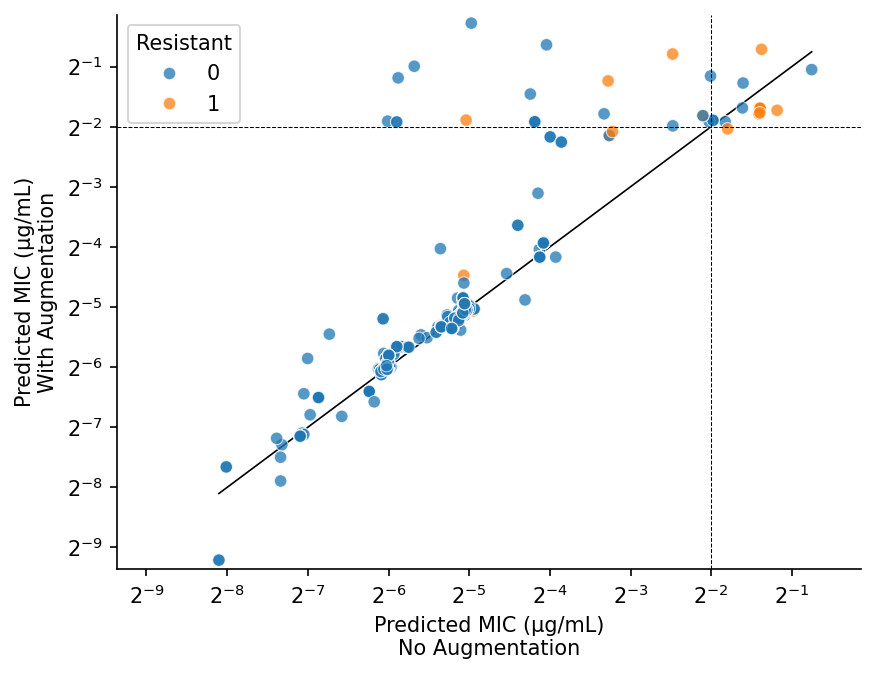

In [27]:
sns.scatterplot(data=df_test,
                x='y_pred_exp',
                y='y_pred_augmented_exp',
                alpha=0.75,
                hue='Resistant'
               )

plt.xscale('log', base=2)
plt.yscale('log', base=2)

plt.plot(np.linspace(df_test['y_pred_exp'].min(), df_test['y_pred_exp'].max(), 10),
         np.linspace(df_test['y_pred_exp'].min(), df_test['y_pred_exp'].max(), 10),
         color='black',
         zorder=0,
         linewidth=0.8,
        )

plt.axhline(y=0.25, linestyle='--', color='black', linewidth=0.5)
plt.axvline(x=0.25, linestyle='--', color='black', linewidth=0.5)

max_val = df_test[['y_pred_exp', 'y_pred_augmented_exp']].values.max()
min_val = df_test[['y_pred_exp', 'y_pred_augmented_exp']].values.min()

plt.xlim(min_val*0.9, max_val*1.1)
plt.ylim(min_val*0.9, max_val*1.1)

plt.xlabel('Predicted MIC (µg/mL)\nNo Augmentation')
plt.ylabel('Predicted MIC (µg/mL)\nWith Augmentation')

sns.despine()
plt.savefig("./results/Bedaquiline/test_predictions_augmentation_compare.svg", bbox_inches='tight')

# Compare how many Group 1-2 variants are associated with R after augmentation

In [8]:
df_insilico_pred = pd.read_csv("./results/Bedaquiline/insilico_pred_no_augment.csv")
df_insilico_pred_augmented = pd.read_csv("./supplement/insilico_pred_all.csv").query("drug=='Bedaquiline'")

len(df_insilico_pred), len(df_insilico_pred_augmented)

(737, 737)

In [9]:
df_insilico_pred = df_insilico_pred.merge(df_insilico_pred_augmented[['variant', 'log2_pred_MIC', 'pred_MIC']].rename(columns={'log2_pred_MIC': 'log2_pred_MIC_augmented', 'pred_MIC': 'pred_MIC_augmented'}))

df_insilico_pred['diff'] = df_insilico_pred['pred_MIC_augmented'] - df_insilico_pred['pred_MIC']

# this is equivalent to log2 FC
df_insilico_pred['log2_diff'] = df_insilico_pred['log2_pred_MIC_augmented'] - df_insilico_pred['log2_pred_MIC']

df_insilico_pred['diff_FC'] = df_insilico_pred['pred_MIC_augmented'] / df_insilico_pred['pred_MIC']

In [10]:
df_insilico_pred['diff'].mean(), df_insilico_pred['diff_FC'].mean()

(0.03273942695359566, 1.8705664306187861)

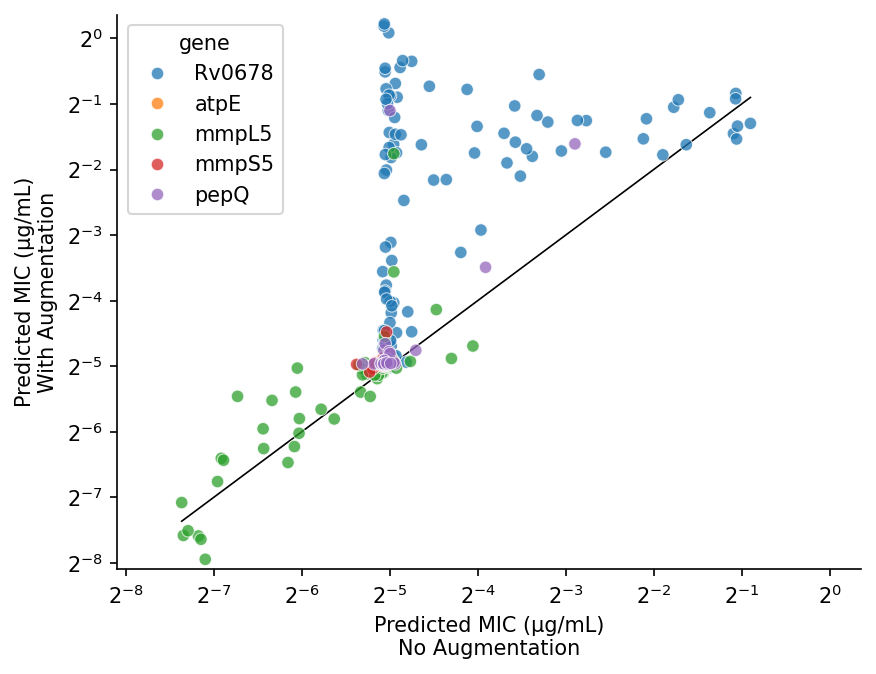

In [14]:
sns.scatterplot(data=df_insilico_pred.query("variant != 'MT_H37Rv'"),
                x='pred_MIC',
                y='pred_MIC_augmented',
                hue='gene',
                alpha=0.75
               )

plt.xscale('log', base=2)
plt.yscale('log', base=2)

plt.plot(np.linspace(df_insilico_pred['pred_MIC'].min(), df_insilico_pred['pred_MIC'].max(), 10),
         np.linspace(df_insilico_pred['pred_MIC'].min(), df_insilico_pred['pred_MIC'].max(), 10),
         color='black',
         zorder=0,
         linewidth=0.8
        )

max_val = df_insilico_pred[['pred_MIC', 'pred_MIC_augmented']].values.max()
min_val = df_insilico_pred[['pred_MIC', 'pred_MIC_augmented']].values.min()

plt.xlim(min_val*0.9, max_val*1.1)
plt.ylim(min_val*0.9, max_val*1.1)

plt.xlabel('Predicted MIC (µg/mL)\nNo Augmentation')
plt.ylabel('Predicted MIC (µg/mL)\nWith Augmentation')

sns.despine()
plt.savefig("./results/Bedaquiline/insilico_predictions_augmentation_compare.svg", bbox_inches='tight')

In [17]:
df_insilico_pred.groupby('gene')[['diff', 'log2_diff', 'diff_FC']].mean()

,diff,log2_diff,diff_FC
gene,,,
MT_H37Rv,0.002244,0.104633,1.075221
Rv0678,0.111493,0.987265,3.907546
atpE,0.002677,0.120870,1.088750
mmpL5,0.003045,0.115875,1.109106
mmpS5,0.002592,0.119866,1.087847
pepQ,0.008327,0.155934,1.221869


In [95]:
isolate_variants.query("variant=='pepQ_p.Glu339del'")

,ROLLINGDB_ID,POS,REF,ALT,FILTER,QUAL,IMPRECISE,AF,DP,BQ,MQ,IC,DC,EFFECT,GENE,HGVS_C,HGVS_P,variant,drug,confidence


In [34]:
df_insilico_pred.query("diff > 0.1 & gene=='pepQ'")

,variant,log2_pred_MIC,pred_MIC,effect,CC,Locus,confidence,ref_pred,fold_change,log2_fold_change,gene,drug,log2_pred_MIC_augmented,pred_MIC_augmented,diff,diff_FC,log2_diff
694,pepQ_p.Gln5*,-2.894803,0.134455,stop_gained,0.25,pepQ,2) Assoc w R - Interim,0.029826,4.507967,2.172477,pepQ,Bedaquiline,-1.608892,0.327850,0.193395,2.438360,1.285911
699,pepQ_p.Glu339del,-4.997703,0.031300,inframe_deletion,0.25,pepQ,3) Uncertain significance,0.029826,1.049409,0.069578,pepQ,Bedaquiline,-1.099777,0.466589,0.435289,14.907078,3.897926


In [32]:
df_insilico_pred.query("confidence=='4) Not assoc w R - Interim' & pred_MIC_augmented > 0.05")

,variant,log2_pred_MIC,pred_MIC,effect,CC,Locus,confidence,ref_pred,fold_change,log2_fold_change,gene,drug,log2_pred_MIC_augmented,pred_MIC_augmented,diff,diff_FC,log2_diff
292,mmpL5_c.2889G>A,-4.953423,0.032275,synonymous_variant,0.25,mmpLS5,4) Not assoc w R - Interim,0.029826,1.082118,0.113858,mmpL5,Bedaquiline,-1.757820,0.295695,0.263419,9.161619,3.195603
307,mmpL5_c.661C>T,-4.953257,0.032279,synonymous_variant,0.25,mmpLS5,4) Not assoc w R - Interim,0.029826,1.082242,0.114024,mmpL5,Bedaquiline,-3.560688,0.084747,0.052468,2.625457,1.392568


In [185]:
# 963
isolate_variants.query("GENE=='mmpL5' & variant.str.contains('2890')").drop_duplicates(['ROLLINGDB_ID']).merge(df_BDQ)

,POS,REF,ALT,FILTER,QUAL,IMPRECISE,AF,DP,BQ,MQ,...,Lipworth2019,Shitikov2017,Stucki2016,F2,Lineage,log2_F2,Span_CC,Binary,Stratify,category


In [18]:
search_isolates = isolate_variants.query("variant=='mmpL5_c.2889G>A'").drop_duplicates(['ROLLINGDB_ID']).merge(df_BDQ).ROLLINGDB_ID.unique()

isolate_variants.query("variant=='mmpL5_c.2889G>A'").drop_duplicates(['ROLLINGDB_ID']).merge(df_BDQ)

,ROLLINGDB_ID,POS,REF,ALT,FILTER,QUAL,IMPRECISE,AF,DP,BQ,...,Lipworth2019,Shitikov2017,Stucki2016,F2,Lineage,log2_F2,Span_CC,Binary,Stratify,category
0,SAMN37124293,775592,C,T,PASS,4137.0,False,0.94,157.0,35.0,...,beijing,"lin2.2.1,asian_african_2",NaN,0.022537,2,-5.471547,0,0.0,2-0,train_set
1,TN15536,775592,C,T,PASS,4284.0,False,0.99,148.0,30.0,...,"beijing,mungi","lin2.2.1,asian_african_2",NaN,0.017251,2,-5.857215,0,0.0,2-0,test_set
2,TRL0074347,775592,C,T,PASS,3361.0,False,1.00,102.0,33.0,...,"beijing,mungi","lin2.2.1,asian_african_2",NaN,0.011672,2,-6.420800,0,0.0,2-0,test_set
3,SAMEA8718840,775592,C,T,PASS,4859.0,False,1.00,135.0,36.0,...,"beijing,mungi","lin2.2.1,asian_african_2",NaN,0.015337,2,-6.026812,0,0.0,2-0,train_set
4,SAMEA8718899,775592,C,T,PASS,5295.0,False,1.00,152.0,35.0,...,"beijing,mungi","lin2.2.1,asian_african_2",NaN,0.008018,2,-6.962498,0,0.0,2-0,test_set
5,SAMEA8719036,775592,C,T,PASS,4625.0,False,1.00,129.0,36.0,...,beijing,"lin2.2.1,asian_african_2",NaN,0.007618,2,-7.036382,0,0.0,2-0,train_set


In [28]:
df_BDQ.groupby('Coll2014')[['Binary', 'BDQ_midpoint']].mean().sort_values("BDQ_midpoint")#.loc['2.2.1']

,Binary,BDQ_midpoint
Coll2014,,
1.1.1.1,0.000000,0.009647
4.3.4,0.000000,0.015000
"3,4",0.000000,0.015000
2.2.1.2,0.000000,0.016154
4.2,0.000000,0.016333
...,...,...
3.1.1,0.145455,0.105441
4.1.1.2,0.333333,0.105583
4.4.1.1,0.227425,0.109500


In [22]:
isolate_variants.query("ROLLINGDB_ID in @search_isolates & drug=='Bedaquiline'").query("AF <= 0.75")

,ROLLINGDB_ID,POS,REF,ALT,FILTER,QUAL,IMPRECISE,AF,DP,BQ,MQ,IC,DC,EFFECT,GENE,HGVS_C,HGVS_P,variant,drug,confidence


In [31]:
isolate_variants.query("ROLLINGDB_ID in @search_isolates & drug=='Bedaquiline'").merge(df_BDQ).query("category=='train_set'").variant.value_counts()

variant
mmpL5_c.2889G>A      3
mmpL5_p.Ile948Val    3
mmpL5_p.Thr794Ile    3
mmpL5_p.Asp767Asn    3
Rv1979c_c.-129A>G    3
mtrB_p.Met517Leu     3
mtrB_p.Pro18Ser      3
mtrB_p.Glu429Gly     1
Rv0678_p.Glu49fs     1
Rv0678_LoF           1
Name: count, dtype: int64

In [26]:
df_BDQ.query("ROLLINGDB_ID in @search_isolates")

,ROLLINGDB_ID,BDQ_MEDIA,BDQ_lower_bound,BDQ_midpoint,BDQ_upper_bound,MEDIA,DB_OF_ORIGIN,Coll2014,Freschi2020,Lipworth2019,Shitikov2017,Stucki2016,F2,Lineage,log2_F2,Span_CC,Binary,Stratify,category
1493,SAMEA8718899,7H11,0.120,0.1850,0.250,UKMYC,CRyPTIC,2.2.1,2.2.1.1.1,"beijing,mungi","lin2.2.1,asian_african_2",NaN,0.008018,2,-6.962498,0,0.0,2-0,test_set
1747,TN15536,7H11,0.020,0.0300,0.040,7H10,Kreiswirth,2.2.1,2.2.1.1.1,"beijing,mungi","lin2.2.1,asian_african_2",NaN,0.017251,2,-5.857215,0,0.0,2-0,test_set
1771,TRL0074347,7H11,0.031,0.0465,0.062,BMD,NICD,2.2.1,2.2.1.1.1,"beijing,mungi","lin2.2.1,asian_african_2",NaN,0.011672,2,-6.420800,0,0.0,2-0,test_set
7783,SAMEA8718840,7H11,0.015,0.0225,0.030,UKMYC,CRyPTIC,2.2.1,2.2.1.1.1,"beijing,mungi","lin2.2.1,asian_african_2",NaN,0.015337,2,-6.026812,0,0.0,2-0,train_set
7876,SAMEA8719036,7H11,0.030,0.0450,0.060,UKMYC,CRyPTIC,2.2.1,2.2.1.1.1,beijing,"lin2.2.1,asian_african_2",NaN,0.007618,2,-7.036382,0,0.0,2-0,train_set
8705,SAMN37124293,7H11,0.039,0.0585,0.078,MGIT,Gandhi,2.2.1,2.2.1.1.1,beijing,"lin2.2.1,asian_african_2",NaN,0.022537,2,-5.471547,0,0.0,2-0,train_set


In [178]:
isolate_variants.query("variant=='mmpL5_c.661C>T'").drop_duplicates(['ROLLINGDB_ID']).merge(df_BDQ)[['BDQ_lower_bound', 'BDQ_upper_bound']]

,BDQ_lower_bound,BDQ_upper_bound
0,0.015,0.03
1,0.060,0.12
2,0.030,0.06
3,0.030,0.06
4,0.030,0.06
5,0.030,0.06
6,0.060,0.12
